# Comandos para realização do trabalho da matéria de NLP com uso da biblioteca SKlearn e NLTK.

## <font color=red>Observação importante:</font>

<font color=yellow>Trabalho realizado com uso de corpus diferente do Fake.br não será aceito!</font>

## Carregando arquivos `pre-processed.csv`, de imagem e de funções auxiliares para dentro do Google Colab

In [1]:
import os
import urllib.request

# Baixa o pre-processed.csv (necessário em qualquer ambiente: Colab, VS Code, Jupyter local)
if not os.path.exists("pre-processed.csv"):
    url = "https://raw.githubusercontent.com/roneysco/Fake.br-Corpus/master/preprocessed/pre-processed.csv"
    urllib.request.urlretrieve(url, "pre-processed.csv")
    print("pre-processed.csv baixado com sucesso.")
else:
    print("pre-processed.csv já existe, pulando download.")

# Se você já tem a pasta "data/" e o "funcoes_auxiliares.py" (como no NLP.zip fornecido),
# não é necessário clonar o repositório novamente. Caso não tenha, descomente as linhas abaixo:
# !git clone https://github.com/N-CPUninter/NLP.git
# !rm ./NLP/*.ipynb
# !mv ./NLP/* .
# !rm -r NLP


pre-processed.csv baixado com sucesso.


## Instalação manual das dependências para uso do SKlearn e do NLTK no Google Colab

In [2]:
import pandas as pd
import numpy as np
import nltk
from nltk import ngrams
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

from funcoes_auxiliares import gerar_nuvem_palavras

# Baixamos apenas os pacotes NLTK necessários (mais rápido que nltk.download("all"))
nltk.download("stopwords")
nltk.download("rslp")
nltk.download("punkt")
nltk.download("punkt_tab")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\alfca\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package rslp to
[nltk_data]     C:\Users\alfca\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping stemmers\rslp.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\alfca\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\alfca\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

## Criar dataframe do CSV utilizando o método read_csv do pandas

In [3]:
df = pd.read_csv('pre-processed.csv')

# Verificação de importação: garante que os textos vieram sem erro de
# acentuação/encoding e confirma o nome real das colunas do dataset
print("Colunas encontradas:", list(df.columns))
print("Formato do dataframe:", df.shape)
display(df.head(3))

# Caso as colunas venham com nomes diferentes do esperado, padronizamos
colunas_esperadas = ['index', 'label', 'preprocessed_news']
if not {'label', 'preprocessed_news'}.issubset(df.columns):
    df.columns = colunas_esperadas[:len(df.columns)]

df['label'] = df['label'].astype(str).str.lower().str.strip()
print("\nDistribuição de rótulos:")
print(df['label'].value_counts())


Colunas encontradas: ['index', 'label', 'preprocessed_news']
Formato do dataframe: (7200, 3)


,index,label,preprocessed_news
0,0,fake,katia abreu diz vai colocar expulsao moldura n...
1,1,fake,ray peita bolsonaro conservador fake entrevist...
2,2,fake,reinaldo azevedo desmascarado policia federal ...



Distribuição de rótulos:
label
fake    3600
true    3600
Name: count, dtype: int64


# PRÁTICA 1 - CRIAÇÃO DE MODELO DE CLASSIFICAÇÃO SUPERVISIONADO PARA ANÁLISE DE FAKE NEWS.

1. Realize os seguintes procedimentos de limpeza dos textos do dataframe criado:

  1.1. Tokenizar

  1.2. Retirar os acentos e números

  1.3. Deixar tudo em minúsculas

  1.4. Retirar as stopwords e pontuações

  1.5. Deixar palavras apenas com radical (STEM)

  1.6. Realizar truncamento dos pares de notícias verdadeiras com falsas para normalizar quantidade de palavras

  1.7. Remontar as notícias em string e criar coluna no dataframe para o resultado deste pré-processamento.

2. Criar matriz de frequências TF-IDF com ngramas de 1 a 3 palavras.

3. Usar a função train_test_split do Scikit Learn para dividir o corpus pré-tratado em 75% dos textos para treinamento e 25% para testes de precisão (usar random_state = 42 ou outro número de sua escolha).

4. Fazer regressão logística com solver = 'lbfgs'.

5. Realizar predição dos textos de teste com o método predict_proba, que retornará a porcentagem predita para fake e para real em um array.

6. Por fim, com as porcentagens calculadas para cada texto de teste, usar a função accuracy_score da biblioteca Scikit Learn para calcular a acurácia geral do algoritmo.

In [4]:
# ============================================================
# Identificador Pessoal (RU) - exigido pelo roteiro em todo o código
# ============================================================
RU_351946 = 351946

import re
import string
import unicodedata
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer
from nltk.tokenize import word_tokenize

stemmer_351946 = RSLPStemmer()
stopwords_pt = set(stopwords.words('portuguese'))

# ------------------------------------------------------------------
# 1.1 a 1.5: Funções de limpeza e tokenização
# ------------------------------------------------------------------
def remover_acentos(texto):
    """Remove acentuação e diacríticos de um texto."""
    texto_nfkd = unicodedata.normalize('NFKD', str(texto))
    return ''.join(c for c in texto_nfkd if not unicodedata.combining(c))


def limpar_e_tokenizar(texto):
    """
    Pipeline de pré-processamento de cada notícia:
      - remove acentos e números
      - converte para minúsculas
      - tokeniza
      - remove stopwords e pontuação
      - aplica stemming (radicalização) com RSLP
    Retorna a lista de tokens (radicais) resultante.
    """
    texto = remover_acentos(texto)
    texto = texto.lower()
    texto = re.sub(r'\d+', ' ', texto)                         # remove números
    texto = texto.translate(str.maketrans('', '', string.punctuation))  # remove pontuação
    tokens = word_tokenize(texto, language='portuguese')
    tokens = [t for t in tokens if t.isalpha()]                # só letras
    tokens = [t for t in tokens if t not in stopwords_pt]      # remove stopwords
    tokens = [stemmer_351946.stem(t) for t in tokens]           # radicalização (STEM)
    return tokens


print("Processando textos (pode levar alguns minutos)...")
df['tokens'] = df['preprocessed_news'].apply(limpar_e_tokenizar)
df['n_tokens'] = df['tokens'].apply(len)
print("Pré-processamento concluído.")
print(df[['label', 'n_tokens']].groupby('label').mean())

# ------------------------------------------------------------------
# 1.6: Truncamento para normalizar a quantidade de palavras
#      (textos FAKE costumam ser bem mais curtos que os REAL;
#      truncamos todos os textos para o tamanho médio dos textos FAKE,
#      evitando que o modelo aprenda a diferenciar as classes apenas
#      pelo tamanho do texto e não pelo conteúdo)
# ------------------------------------------------------------------
tam_corte_351946 = int(df.loc[df['label'] == 'fake', 'n_tokens'].mean())
print(f"\nTamanho de corte usado no balanceamento: {tam_corte_351946} tokens")

df['tokens_truncados'] = df['tokens'].apply(lambda t: t[:tam_corte_351946])

# ------------------------------------------------------------------
# 1.7: Remontar os textos processados em uma nova coluna
# ------------------------------------------------------------------
df['texto_final'] = df['tokens_truncados'].apply(lambda t: ' '.join(t))
print(df[['label', 'texto_final']].head(2))

# ------------------------------------------------------------------
# 2. Matriz de frequências TF-IDF com n-gramas de 1 a 3
# ------------------------------------------------------------------
vetorizador_351946 = TfidfVectorizer(ngram_range=(1, 3), min_df=5, max_features=6000)
X = vetorizador_351946.fit_transform(df['texto_final'])
y = df['label']
print(f"\nDimensão da matriz TF-IDF: {X.shape}")

# ------------------------------------------------------------------
# 3. Separação treino (75%) / teste (25%)
# ------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# ------------------------------------------------------------------
# 4. Regressão Logística (solver='lbfgs')
# ------------------------------------------------------------------
modelo_351946 = LogisticRegression(solver='lbfgs', max_iter=1000)
modelo_351946.fit(X_train, y_train)

# ------------------------------------------------------------------
# 5. Predição com predict_proba
# ------------------------------------------------------------------
probabilidades_351946 = modelo_351946.predict_proba(X_test)
classes_351946 = modelo_351946.classes_
y_pred_351946 = classes_351946[np.argmax(probabilidades_351946, axis=1)]

# ------------------------------------------------------------------
# 6. Acurácia
# ------------------------------------------------------------------
acuracia_351946 = accuracy_score(y_test, y_pred_351946)

print(f"\nTotal de termos (uni+bi+trigramas) no vocabulário TF-IDF: {X.shape[1]}")
print(f"ACURÁCIA DO MODELO (RU {RU_351946}): {acuracia_351946*100:.2f}%")


Processando textos (pode levar alguns minutos)...
Pré-processamento concluído.
         n_tokens
label            
fake   107.417778
true   621.888056

Tamanho de corte usado no balanceamento: 107 tokens
  label                                        texto_final
0  fake  kat abr diz vai coloc expulsa mold nao reclam ...
1  fake  ray peit bolsonar conserv fak entrev danil gen...

Dimensão da matriz TF-IDF: (7200, 6000)

Total de termos (uni+bi+trigramas) no vocabulário TF-IDF: 6000
ACURÁCIA DO MODELO (RU 351946): 90.83%


## QUESTÃO 01: Apresente aqui o código referente ao modelo gerado e a nuvem de palavras que foram usadas para identificar textos VERDADEIROS.

1. Formate seus dados usados para o treinamento do seu modelo em um dicionário de tokens e suas frequências.
2. Separe os dados em um grupo com textos marcados como verdadeiros e outro com os falsos.
3. Use a função gerar_nuvem_palavras(dic_de_frequências_textos_verdadeiras, imagem de sua escolha) para gerar a nuvem de palavras


Quantidade de palavras/bigramas/trigramas usados dos textos REAL: 5952
Acurácia do modelo: 90.83%
   * Um total de 5953 tokens foram computadas a partir do conjunto de dados.



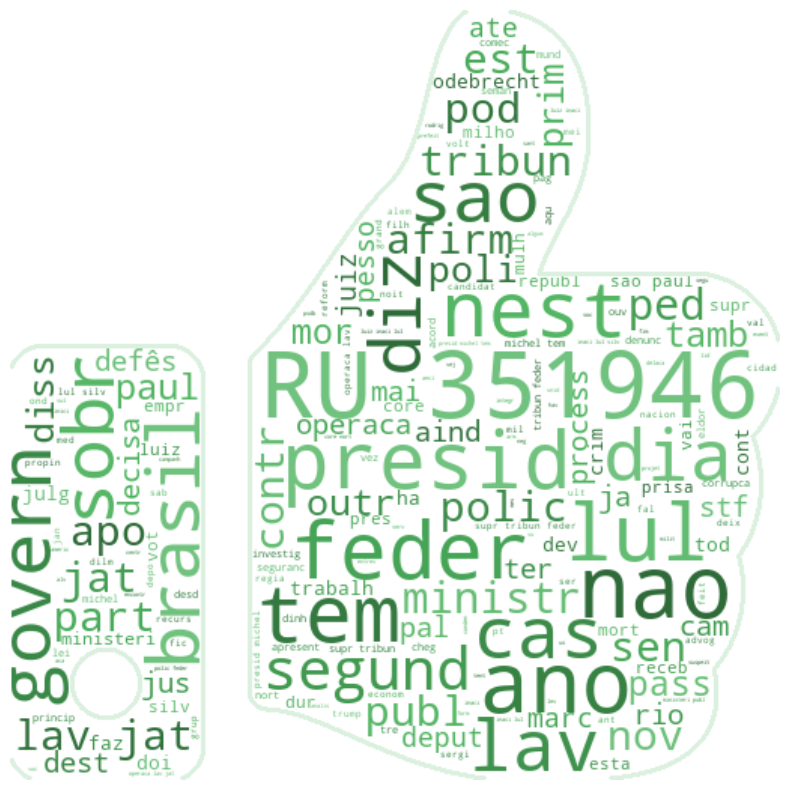

In [5]:
# ============================================================
# QUESTÃO 01 - Nuvem de palavras dos termos usados para textos REAL
# ============================================================
RU_351946_q1 = 351946

feature_names_351946 = np.array(vetorizador_351946.get_feature_names_out())

# Máscara booleana das linhas de TREINO rotuladas como REAL ('true')
mascara_real_351946 = (y_train.values == 'true')

# Soma dos pesos TF-IDF de cada termo, considerando apenas os textos REAL usados no treino
soma_tfidf_real_351946 = np.asarray(X_train[mascara_real_351946].sum(axis=0)).flatten()

dic_real_351946 = {
    palavra: freq
    for palavra, freq in zip(feature_names_351946, soma_tfidf_real_351946)
    if freq > 0
}

qtd_termos_real_351946 = len(dic_real_351946)
print(f"Quantidade de palavras/bigramas/trigramas usados dos textos REAL: {qtd_termos_real_351946}")
print(f"Acurácia do modelo: {acuracia_351946*100:.2f}%")

# Insere o identificador pessoal (RU) como um termo de destaque na nuvem
dic_real_351946['RU 351946'] = max(dic_real_351946.values()) * 1.2

nuvem_real_351946, _ = gerar_nuvem_palavras(
    dicionario_tokens_e_frequencia=dic_real_351946,
    arquivo_mascara='thumbs_up_mask.png'
)


## QUESTÃO 02: Apresente aqui o código referente ao modelo gerado e a nuvem de palavras que foram usadas para identificar textos FALSOS.

1. Use a função gerar_nuvem_palavras(dic_de_frequências_textos_verdadeiras, imagem de sua escolha) para gerar a nuvem de palavras

Quantidade de palavras/bigramas/trigramas usados dos textos FAKE: 5869
Técnicas de pré-processamento utilizadas: remoção de acentos/números, minúsculas,
tokenização (NLTK), remoção de stopwords e pontuação, stemming (RSLP) e truncamento
para balanceamento de tamanho entre as classes.
Tipo de modelo: Regressão Logística (solver='lbfgs') treinada sobre matriz TF-IDF (1 a 3 n-gramas).
   * Um total de 5870 tokens foram computadas a partir do conjunto de dados.



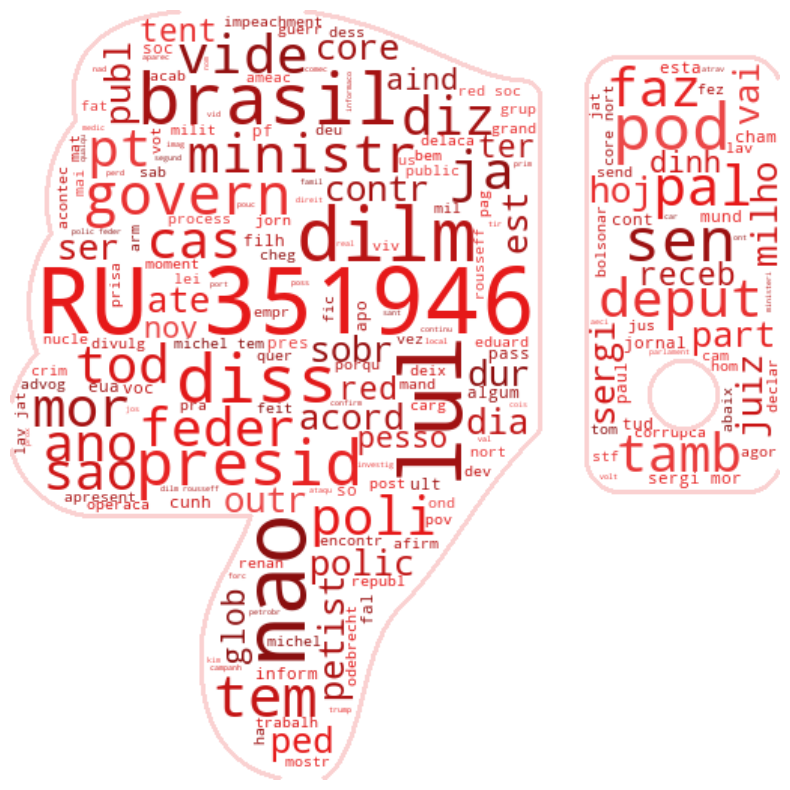

In [6]:
# ============================================================
# QUESTÃO 02 - Nuvem de palavras dos termos usados para textos FAKE
# ============================================================
RU_351946_q2 = 351946

# Máscara booleana das linhas de TREINO rotuladas como FAKE
mascara_fake_351946 = (y_train.values == 'fake')

# Soma dos pesos TF-IDF de cada termo, considerando apenas os textos FAKE usados no treino
soma_tfidf_fake_351946 = np.asarray(X_train[mascara_fake_351946].sum(axis=0)).flatten()

dic_fake_351946 = {
    palavra: freq
    for palavra, freq in zip(feature_names_351946, soma_tfidf_fake_351946)
    if freq > 0
}

qtd_termos_fake_351946 = len(dic_fake_351946)
print(f"Quantidade de palavras/bigramas/trigramas usados dos textos FAKE: {qtd_termos_fake_351946}")
print("Técnicas de pré-processamento utilizadas: remoção de acentos/números, minúsculas,")
print("tokenização (NLTK), remoção de stopwords e pontuação, stemming (RSLP) e truncamento")
print("para balanceamento de tamanho entre as classes.")
print("Tipo de modelo: Regressão Logística (solver='lbfgs') treinada sobre matriz TF-IDF (1 a 3 n-gramas).")

# Insere o identificador pessoal (RU) como um termo de destaque na nuvem
dic_fake_351946['RU 351946'] = max(dic_fake_351946.values()) * 1.2

nuvem_fake_351946, _ = gerar_nuvem_palavras(
    dicionario_tokens_e_frequencia=dic_fake_351946,
    arquivo_mascara='thumbs_down_mask.png'
)


---

# Material Complementar

## Alguns exemplos de uso da função auxiliar
`gerar_nuvem_palavras(dicionario_tokens_e_frequencia, arquivo_mascara)`

Gera uma nuvem de palavras com base em seu dicionário de palavras ou ngramas
    como a chave e a frequência de aparição do token como valor (inteiro).

    Parâmetros:
        dicionario_tokens_e_frequencia (dict): O dicionário de tokens e suas
                                               respectivas frequências de
                                               aparição nos textos.
        arquivo_mascara (str): O nome do arquivo da imagem de máscara. Pde ser:
                                            cloud_mask.png
                                            mapa_brasil_mask.png
                                            thumbs_up_mask.png        
                                            thumbs_down_mask.png
                                            <Outro arquivo de sua escolha>

    Exemplos de Uso:
        1. Para gerar uma nuvem de palavras na máscara mapa do brasil:
            gerar_nuvem_palavras(dicionario_tokens_e_frequencia=word_dict,
                                 arquivo_mascara='mapa_brasil_mask.png')

   * Um total de 7 tokens foram computadas a partir do conjunto de dados.



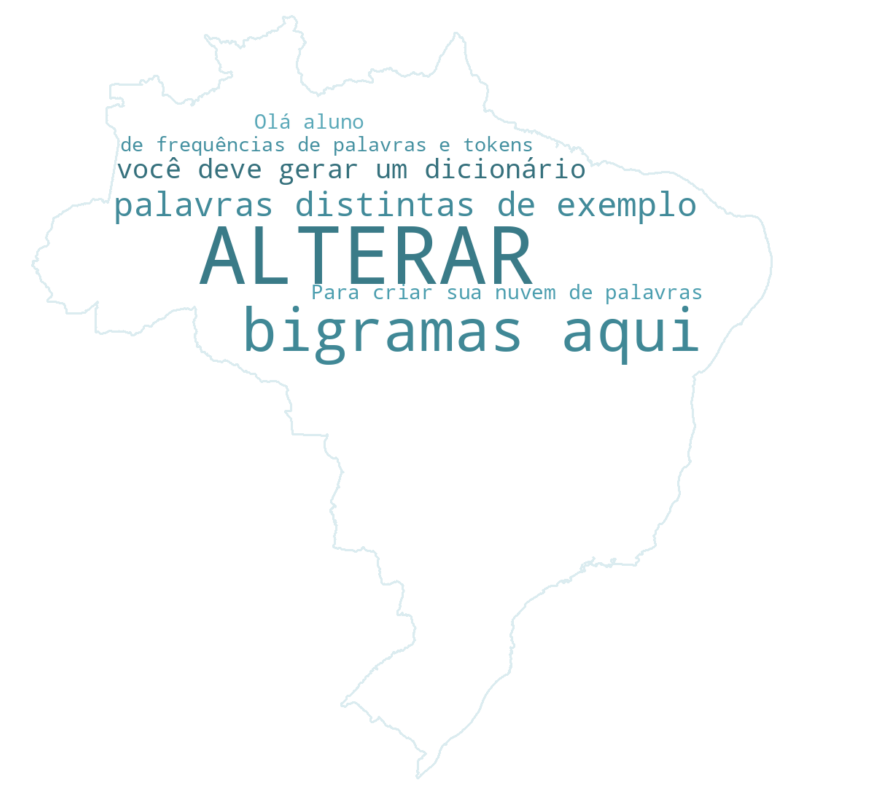

(<wordcloud.wordcloud.WordCloud at 0x784fdddbed40>, 7)

In [5]:
# Exemplo com dicionário de tokens unigramas e multigramas com frequências
words_dict = {'Olá aluno':1,
              'ALTERAR':4,
              'bigramas aqui':2,
              'palavras distintas de exemplo':2,
              'Para criar sua nuvem de palavras':1,
              'você deve gerar um dicionário':2,
              'de frequências de palavras e tokens':1}
gerar_nuvem_palavras(dicionario_tokens_e_frequencia=words_dict,
                     arquivo_mascara="mapa_brasil_mask.png")

{'de palavras': 2, 'exemplo gerar': 1, 'gerar uma': 1, 'uma nuvem': 1, 'nuvem de': 1, 'palavras usando': 1, 'usando texto': 1, 'texto completo': 1, 'completo você': 1, 'você deve': 1, 'deve primeiro': 1, 'primeiro separar': 1, 'separar ele': 1, 'ele um': 1, 'um um': 1, 'um ou': 1, 'ou mais': 1, 'mais tokens': 1, 'tokens para': 1, 'para só': 1, 'só depois': 1, 'depois vetorizar': 1, 'vetorizar ao': 1, 'ao vetorizar': 1, 'vetorizar você': 1, 'você terá': 1, 'bag of': 1, 'of words': 1, 'words que': 1, 'que te': 1, 'te permitirá': 1, 'permitirá contar': 1, 'contar quantas': 1, 'quantas vezes': 1, 'vezes cada': 1, 'cada palavra': 1, 'palavra ou': 1, 'ou grupo': 1, 'grupo de': 1, 'palavras aparecem': 1, 'aparecem no': 1, 'no texto': 1, 'texto por': 1, 'por fim': 1, 'fim basta': 1, 'basta criar': 1, 'criar um': 1, 'um dicionário': 1, 'dicionário contendo': 1, 'chave como': 1, 'seu token': 1, 'valor como': 1, 'frequência de': 1, 'de aparição': 1, 'aparição deste': 1, 'deste tokem': 1}
   * Um 

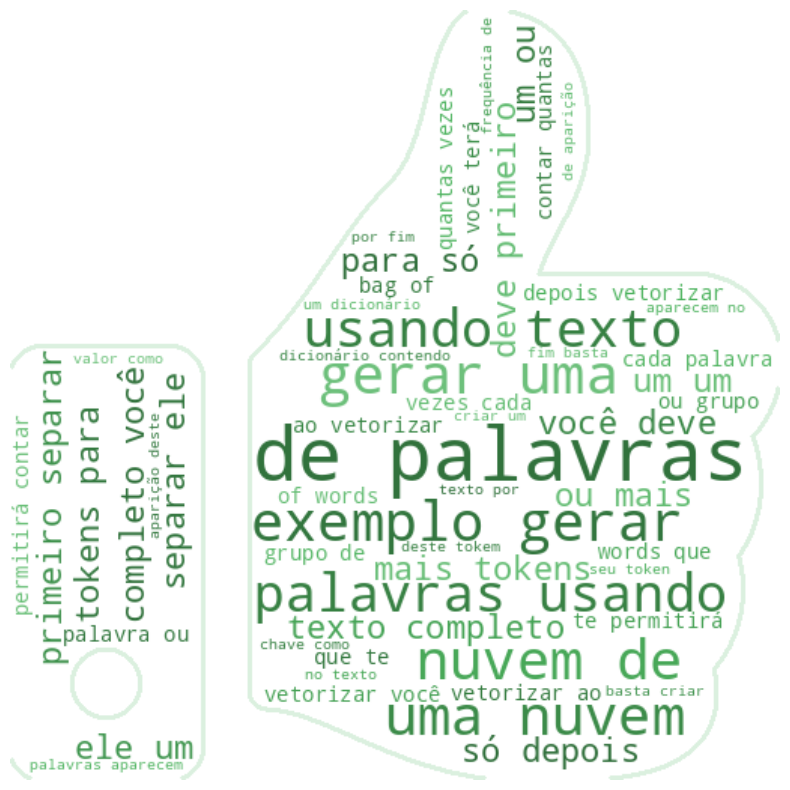

(<wordcloud.wordcloud.WordCloud at 0x784fdddbef20>, 56)

In [6]:
# Exemplo com uma frase completa
texto = """Exemplo: Gerar uma nuvem de palavras usando texto completo você deve
           primeiro separar ele um um ou mais tokens, para só depois vetorizar.
           Ao vetorizar você terá a bag of words, que te permitirá contar
           quantas vezes cada palavra ou grupo de palavras aparecem no texto.
           Por fim, basta criar um dicionário contendo a chave como o seu token
           e o valor como a frequência de aparição deste tokem."""
# Vetorização e contagem de frequência simples de bigramas:
vectorizer = CountVectorizer(ngram_range=(2, 2))
bag_of_words = vectorizer.fit_transform([a+' '+b for a,b in (ngrams(texto.split(),2))])
sum_words = bag_of_words.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
words_dict = dict(words_freq)
print(words_dict)

gerar_nuvem_palavras(dicionario_tokens_e_frequencia=words_dict,
                      arquivo_mascara='thumbs_up_mask.png')